# Cross-Encoder Fine-tuning for CHIVA Clinical RAG
## Training a domain-specific relevance model for ligation knowledge retrieval

This notebook fine-tunes a cross-encoder model on synthetic CHIVA clinical data to improve relevance ranking in the RAG pipeline.

## 1. Setup and Imports

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("[OK] All imports successful")

[OK] All imports successful


## 2. Load Synthetic Training Data

In [2]:
# Load the synthetic training data
data_path = Path("synthetic_training_data.json")

with open(data_path, 'r') as f:
    data = json.load(f)

metadata = data['metadata']
train_data = data['train']
val_data = data['val']
test_data = data['test']

print("[OK] Data loaded successfully")
print(f"\nDataset Summary:")
print(f"  Total samples: {metadata['total_samples']}")
print(f"  Training set: {metadata['train_size']} samples")
print(f"  Validation set: {metadata['val_size']} samples")
print(f"  Test set: {metadata['test_size']} samples")
print(f"  Source documents: {metadata['num_source_documents']}")

[OK] Data loaded successfully

Dataset Summary:
  Total samples: 770
  Training set: 539 samples
  Validation set: 115 samples
  Test set: 116 samples
  Source documents: 10


## 3. Data Exploration and Visualization

In [3]:
# Convert to DataFrame for analysis
df_train = pd.DataFrame(train_data)
df_val = pd.DataFrame(val_data)
df_test = pd.DataFrame(test_data)

print("Sample Training Examples:")
print("="*80)
for i in range(3):
    item = train_data[i]
    print(f"\nExample {i+1}:")
    print(f"  Type: {item['shunt_type']}")
    print(f"  Label: {item['label']}")
    print(f"  Relevance Score: {item['relevance_score']}")
    print(f"  Query: {item['query'][:60]}...")
    print(f"  Doc: {item['document'][:60]}...")
    print("-"*80)

Sample Training Examples:

Example 1:
  Type: Type 1
  Label: positive
  Relevance Score: 1.0
  Query: How do I ligate Type 1 shunt?...
  Doc: Type 1 venous shunt ligation: SFJ incompetent with N1->N2 en...
--------------------------------------------------------------------------------

Example 2:
  Type: Type 1
  Label: positive
  Relevance Score: 1.0
  Query: Type 1 ligation technique and approach...
  Doc: Type 1 venous shunt ligation: SFJ incompetent with N1->N2 en...
--------------------------------------------------------------------------------

Example 3:
  Type: Type 1
  Label: positive
  Relevance Score: 1.0
  Query: What is the ligation strategy for Type 1?...
  Doc: Type 1 venous shunt ligation: SFJ incompetent with N1->N2 en...
--------------------------------------------------------------------------------


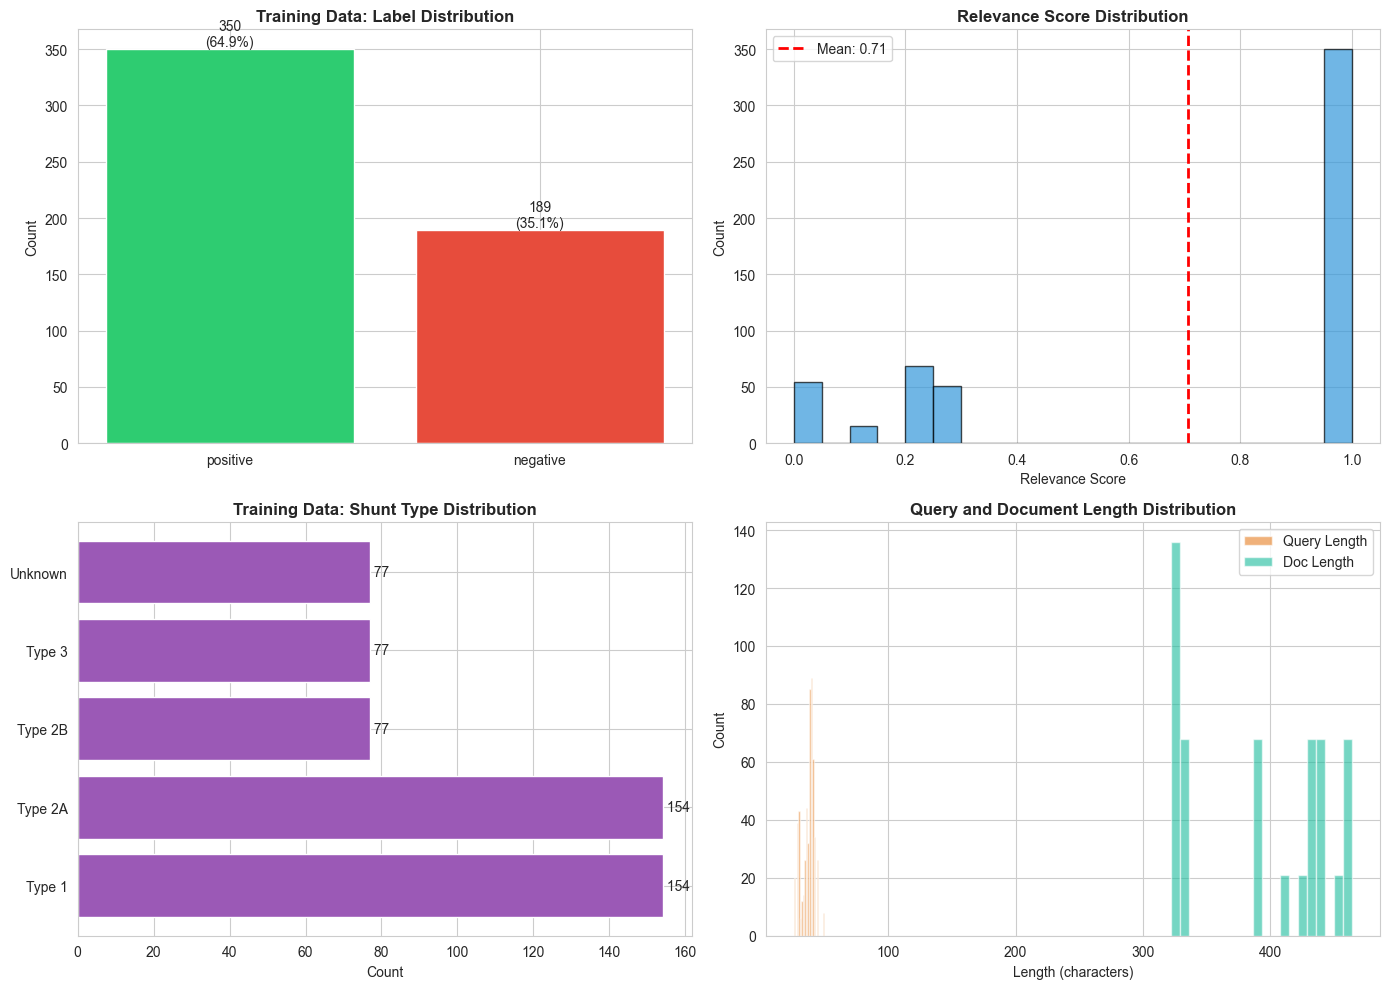


Data Statistics:
  Avg query length: 37.1 chars
  Avg document length: 392.4 chars
  Query length range: 26 - 50
  Document length range: 322 - 464


In [4]:
# Label distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Label distribution
label_counts = Counter(item['label'] for item in train_data)
ax1 = axes[0, 0]
labels = list(label_counts.keys())
counts = list(label_counts.values())
colors = ['#2ecc71', '#e74c3c', '#f39c12']
ax1.bar(labels, counts, color=colors[:len(labels)])
ax1.set_title('Training Data: Label Distribution', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count')
for i, (label, count) in enumerate(zip(labels, counts)):
    ax1.text(i, count, f'{count}\n({count/len(train_data)*100:.1f}%)', ha='center', va='bottom')

# 2. Relevance score distribution
ax2 = axes[0, 1]
relevance_scores = [item['relevance_score'] for item in train_data]
ax2.hist(relevance_scores, bins=20, color='#3498db', edgecolor='black', alpha=0.7)
ax2.set_title('Relevance Score Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Relevance Score')
ax2.set_ylabel('Count')
ax2.axvline(np.mean(relevance_scores), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(relevance_scores):.2f}')
ax2.legend()

# 3. Shunt type distribution
ax3 = axes[1, 0]
shunt_types = Counter(item['shunt_type'] for item in train_data)
shunt_labels = list(shunt_types.keys())
shunt_counts = list(shunt_types.values())
ax3.barh(shunt_labels, shunt_counts, color='#9b59b6')
ax3.set_title('Training Data: Shunt Type Distribution', fontsize=12, fontweight='bold')
ax3.set_xlabel('Count')
for i, count in enumerate(shunt_counts):
    ax3.text(count, i, f' {count}', va='center')

# 4. Query and document length distribution
ax4 = axes[1, 1]
query_lengths = [len(item['query']) for item in train_data]
doc_lengths = [len(item['document']) for item in train_data]
ax4.hist(query_lengths, bins=20, alpha=0.6, label='Query Length', color='#e67e22')
ax4.hist(doc_lengths, bins=20, alpha=0.6, label='Doc Length', color='#1abc9c')
ax4.set_title('Query and Document Length Distribution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Length (characters)')
ax4.set_ylabel('Count')
ax4.legend()

plt.tight_layout()
plt.savefig('01_data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nData Statistics:")
print(f"  Avg query length: {np.mean(query_lengths):.1f} chars")
print(f"  Avg document length: {np.mean(doc_lengths):.1f} chars")
print(f"  Query length range: {min(query_lengths)} - {max(query_lengths)}")
print(f"  Document length range: {min(doc_lengths)} - {max(doc_lengths)}")

## 4. Install Required Libraries

In [5]:
import subprocess
import sys

# Install sentence-transformers if not already installed
try:
    from sentence_transformers import CrossEncoder
    print("[OK] sentence-transformers already installed")
except ImportError:
    print("[INFO] Installing sentence-transformers...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "sentence-transformers", "-q"])
    print("[OK] sentence-transformers installed")

[INFO] Installing sentence-transformers...
[OK] sentence-transformers installed


## 5. Baseline Evaluation (Before Fine-tuning)

In [6]:
from sentence_transformers import CrossEncoder
import torch

# Load pre-trained cross-encoder (baseline)
print("[INFO] Loading pre-trained cross-encoder (baseline)...")
baseline_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
print("[OK] Baseline model loaded")

# Evaluate on test set
print("\n[INFO] Evaluating baseline on test set...")
test_queries = [item['query'] for item in test_data]
test_docs = [item['document'] for item in test_data]
test_labels = np.array([item['relevance_score'] for item in test_data])

# Get predictions
test_pairs = [[q, d] for q, d in zip(test_queries, test_docs)]
baseline_scores = baseline_model.predict(test_pairs)

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import spearmanr

baseline_mse = mean_squared_error(test_labels, baseline_scores)
baseline_mae = mean_absolute_error(test_labels, baseline_scores)
baseline_spearman, baseline_spearman_p = spearmanr(test_labels, baseline_scores)

print(f"\nBaseline Model Performance (Test Set):")
print(f"  MSE: {baseline_mse:.4f}")
print(f"  MAE: {baseline_mae:.4f}")
print(f"  Spearman Correlation: {baseline_spearman:.4f} (p-value: {baseline_spearman_p:.4e})")
print(f"\n  Min score: {baseline_scores.min():.4f}")
print(f"  Max score: {baseline_scores.max():.4f}")
print(f"  Mean score: {baseline_scores.mean():.4f}")

W0430 17:32:46.388000 7340 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


[INFO] Loading pre-trained cross-encoder (baseline)...


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

[OK] Baseline model loaded

[INFO] Evaluating baseline on test set...

Baseline Model Performance (Test Set):
  MSE: 18.1677
  MAE: 3.6832
  Spearman Correlation: 0.2298 (p-value: 1.3065e-02)

  Min score: -5.0406
  Max score: 9.3317
  Mean score: 3.3447


## 6. Prepare Data for Fine-tuning

In [7]:
# Convert training data to format needed by sentence-transformers
# Format: List of (query, document, score) tuples

train_samples = []
for item in train_data:
    train_samples.append((
        item['query'],
        item['document'],
        item['relevance_score']
    ))

val_samples = []
for item in val_data:
    val_samples.append((
        item['query'],
        item['document'],
        item['relevance_score']
    ))

print(f"[OK] Prepared {len(train_samples)} training samples")
print(f"[OK] Prepared {len(val_samples)} validation samples")

# Show sample
print(f"\nSample training pair:")
q, d, s = train_samples[0]
print(f"  Query: {q}")
print(f"  Document: {d[:100]}...")
print(f"  Relevance: {s}")

[OK] Prepared 539 training samples
[OK] Prepared 115 validation samples

Sample training pair:
  Query: How do I ligate Type 1 shunt?
  Document: Type 1 venous shunt ligation: SFJ incompetent with N1->N2 entry and N2->N1 GSV reflux. Primary ligat...
  Relevance: 1.0


## 7. Fine-tune Cross-Encoder

In [8]:
from torch.utils.data import DataLoader , Dataset
from sentence_transformers import InputExample
from sentence_transformers.losses import CosineSimilarityLoss
import torch

# Create model
print("[INFO] Loading model for fine-tuning...")
model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

# Convert to InputExample format
train_examples = [
    InputExample(texts=[q, d], label=float(s))
    for q, d, s in train_samples
]

# Create DataLoader
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

# Set up training
print("[INFO] Starting fine-tuning...")
print(f"  Batch size: 16")
print(f"  Epochs: 10")
print(f"  Learning rate: 2e-5")
print(f"  Warmup steps: 100")
print()

# Create output directory
output_dir = Path("chiva_crossencoder_finetuned")
output_dir.mkdir(exist_ok=True)

# Fine-tune
model.fit(
    train_dataloader=train_dataloader,
    epochs=10,
    warmup_steps=100,
    optimizer_params={"lr": 2e-5},
    evaluator=None,  # We'll evaluate manually
    show_progress_bar=True,
)

# Save model
model.save(str(output_dir))
print(f"\n[OK] Fine-tuning complete!")
print(f"[OK] Model saved to: {output_dir}")

[INFO] Loading model for fine-tuning...
[INFO] Starting fine-tuning...
  Batch size: 16
  Epochs: 10
  Learning rate: 2e-5
  Warmup steps: 100



Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Iteration:   0%|          | 0/34 [00:00<?, ?it/s]

Iteration:   0%|          | 0/34 [00:00<?, ?it/s]

Iteration:   0%|          | 0/34 [00:00<?, ?it/s]

...

Iteration:   0%|          | 0/34 [00:00<?, ?it/s]

Iteration:   0%|          | 0/34 [00:00<?, ?it/s]

Iteration:   0%|          | 0/34 [00:00<?, ?it/s]

Iteration:   0%|          | 0/34 [00:00<?, ?it/s]


[OK] Fine-tuning complete!
[OK] Model saved to: chiva_crossencoder_finetuned


## 8. Evaluate Fine-tuned Model

In [9]:
# Load fine-tuned model
print("[INFO] Loading fine-tuned model...")
finetuned_model = CrossEncoder(str(output_dir))
print("[OK] Fine-tuned model loaded")

# Evaluate on test set
print("\n[INFO] Evaluating fine-tuned model on test set...")
finetuned_scores = finetuned_model.predict(test_pairs)

# Calculate metrics
finetuned_mse = mean_squared_error(test_labels, finetuned_scores)
finetuned_mae = mean_absolute_error(test_labels, finetuned_scores)
finetuned_spearman, finetuned_spearman_p = spearmanr(test_labels, finetuned_scores)

print(f"\nFine-tuned Model Performance (Test Set):")
print(f"  MSE: {finetuned_mse:.4f}")
print(f"  MAE: {finetuned_mae:.4f}")
print(f"  Spearman Correlation: {finetuned_spearman:.4f} (p-value: {finetuned_spearman_p:.4e})")
print(f"\n  Min score: {finetuned_scores.min():.4f}")
print(f"  Max score: {finetuned_scores.max():.4f}")
print(f"  Mean score: {finetuned_scores.mean():.4f}")

[INFO] Loading fine-tuned model...
[OK] Fine-tuned model loaded

[INFO] Evaluating fine-tuned model on test set...

Fine-tuned Model Performance (Test Set):
  MSE: 4.1586
  MAE: 1.5726
  Spearman Correlation: 0.5340 (p-value: 6.7194e-10)

  Min score: -4.3545
  Max score: 5.2455
  Mean score: 0.3990


## 9. Compare Baseline vs Fine-tuned


BASELINE vs FINE-TUNED COMPARISON
              Metric  Baseline  Fine-tuned Improvement
                 MSE 18.167654    4.158551       77.1%
                 MAE  3.683222    1.572617       57.3%
Spearman Correlation  0.229843    0.533967      132.3%


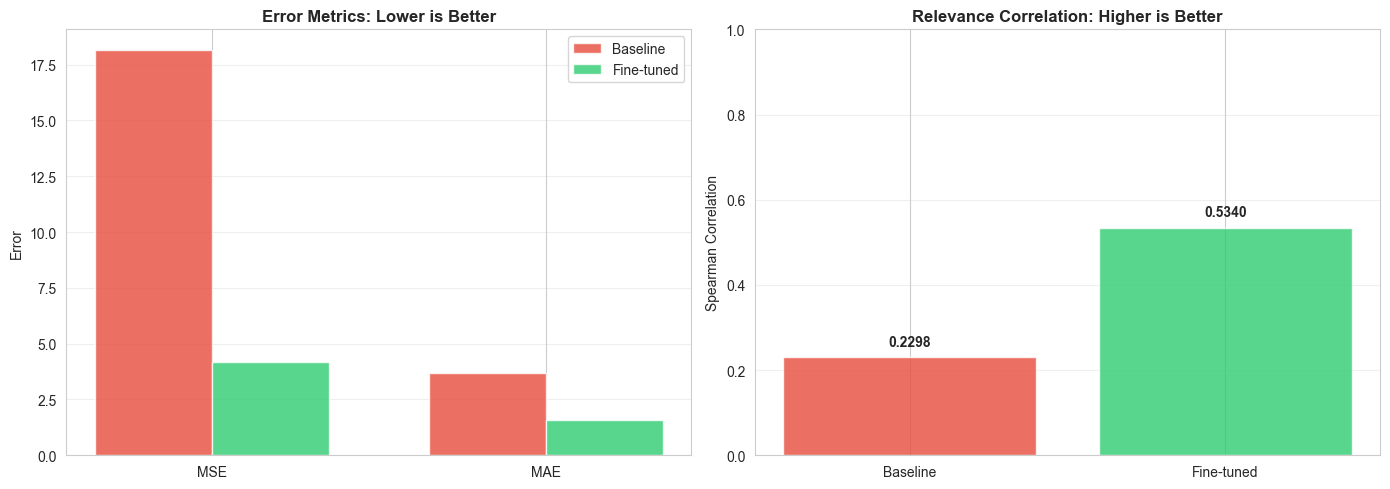

In [10]:
# Create comparison
comparison_df = pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'Spearman Correlation'],
    'Baseline': [baseline_mse, baseline_mae, baseline_spearman],
    'Fine-tuned': [finetuned_mse, finetuned_mae, finetuned_spearman]
})

# Calculate improvements
comparison_df['Improvement'] = [
    f"{(baseline_mse - finetuned_mse) / baseline_mse * 100:.1f}%",
    f"{(baseline_mae - finetuned_mae) / baseline_mae * 100:.1f}%",
    f"{(finetuned_spearman - baseline_spearman) / baseline_spearman * 100:.1f}%"
]

print("\n" + "="*80)
print("BASELINE vs FINE-TUNED COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. MSE and MAE comparison
ax1 = axes[0]
x = np.arange(2)
width = 0.35
ax1.bar(x - width/2, [baseline_mse, baseline_mae], width, label='Baseline', color='#e74c3c', alpha=0.8)
ax1.bar(x + width/2, [finetuned_mse, finetuned_mae], width, label='Fine-tuned', color='#2ecc71', alpha=0.8)
ax1.set_ylabel('Error')
ax1.set_title('Error Metrics: Lower is Better', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(['MSE', 'MAE'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Spearman correlation
ax2 = axes[1]
models = ['Baseline', 'Fine-tuned']
corr_values = [baseline_spearman, finetuned_spearman]
colors = ['#e74c3c', '#2ecc71']
bars = ax2.bar(models, corr_values, color=colors, alpha=0.8)
ax2.set_ylabel('Spearman Correlation')
ax2.set_title('Relevance Correlation: Higher is Better', fontsize=12, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars, corr_values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('02_baseline_vs_finetuned.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Prediction Analysis on Test Set

In [11]:
# Create comparison dataframe for test predictions
test_comparison = pd.DataFrame({
    'Query': test_queries,
    'Document': [d[:50] + '...' for d in test_docs],
    'True_Score': test_labels,
    'Baseline_Score': baseline_scores,
    'Finetuned_Score': finetuned_scores,
})

test_comparison['Baseline_Error'] = abs(test_comparison['True_Score'] - test_comparison['Baseline_Score'])
test_comparison['Finetuned_Error'] = abs(test_comparison['True_Score'] - test_comparison['Finetuned_Score'])

print("Test Set Predictions (first 10 samples):")
print(test_comparison[['Query', 'True_Score', 'Baseline_Score', 'Finetuned_Score', 'Baseline_Error', 'Finetuned_Error']].head(10).to_string())

print(f"\n\nError Summary:")
print(f"  Baseline Mean Error: {test_comparison['Baseline_Error'].mean():.4f}")
print(f"  Fine-tuned Mean Error: {test_comparison['Finetuned_Error'].mean():.4f}")
print(f"  Improvement: {(test_comparison['Baseline_Error'].mean() - test_comparison['Finetuned_Error'].mean()) / test_comparison['Baseline_Error'].mean() * 100:.1f}%")

# Cases where fine-tuned is better
better = (test_comparison['Finetuned_Error'] < test_comparison['Baseline_Error']).sum()
worse = (test_comparison['Finetuned_Error'] > test_comparison['Baseline_Error']).sum()
equal = (test_comparison['Finetuned_Error'] == test_comparison['Baseline_Error']).sum()

print(f"\n  Cases where fine-tuned is better: {better}/{len(test_comparison)} ({better/len(test_comparison)*100:.1f}%)")
print(f"  Cases where baseline is better: {worse}/{len(test_comparison)} ({worse/len(test_comparison)*100:.1f}%)")
print(f"  Cases with equal error: {equal}/{len(test_comparison)} ({equal/len(test_comparison)*100:.1f}%)")

Test Set Predictions (first 10 samples):
                                               Query  True_Score  Baseline_Score  Finetuned_Score  Baseline_Error  Finetuned_Error
0                  Best approach for Type 3 ligation         1.0        6.537103         5.172703        5.537103         4.172703
1                 Surgical steps for Type 3 ligation         1.0        9.331664         1.929067        8.331664         0.929067
2            Type 3 ligation: step-by-step procedure         1.0        7.816509         1.400392        6.816509         0.400392
3            How to perform Type 3 ligation surgery?         1.0        8.891389         2.353011        7.891389         1.353011
4                Surgical technique for Type 3 shunt         1.0        2.576413         2.748336        1.576413         1.748336
5  Type 3 ligation: incision and dissection approach         1.0        5.842037         2.664129        4.842037         1.664129
6           Operating room steps for Type 

## 11. Score Distribution and Calibration Analysis

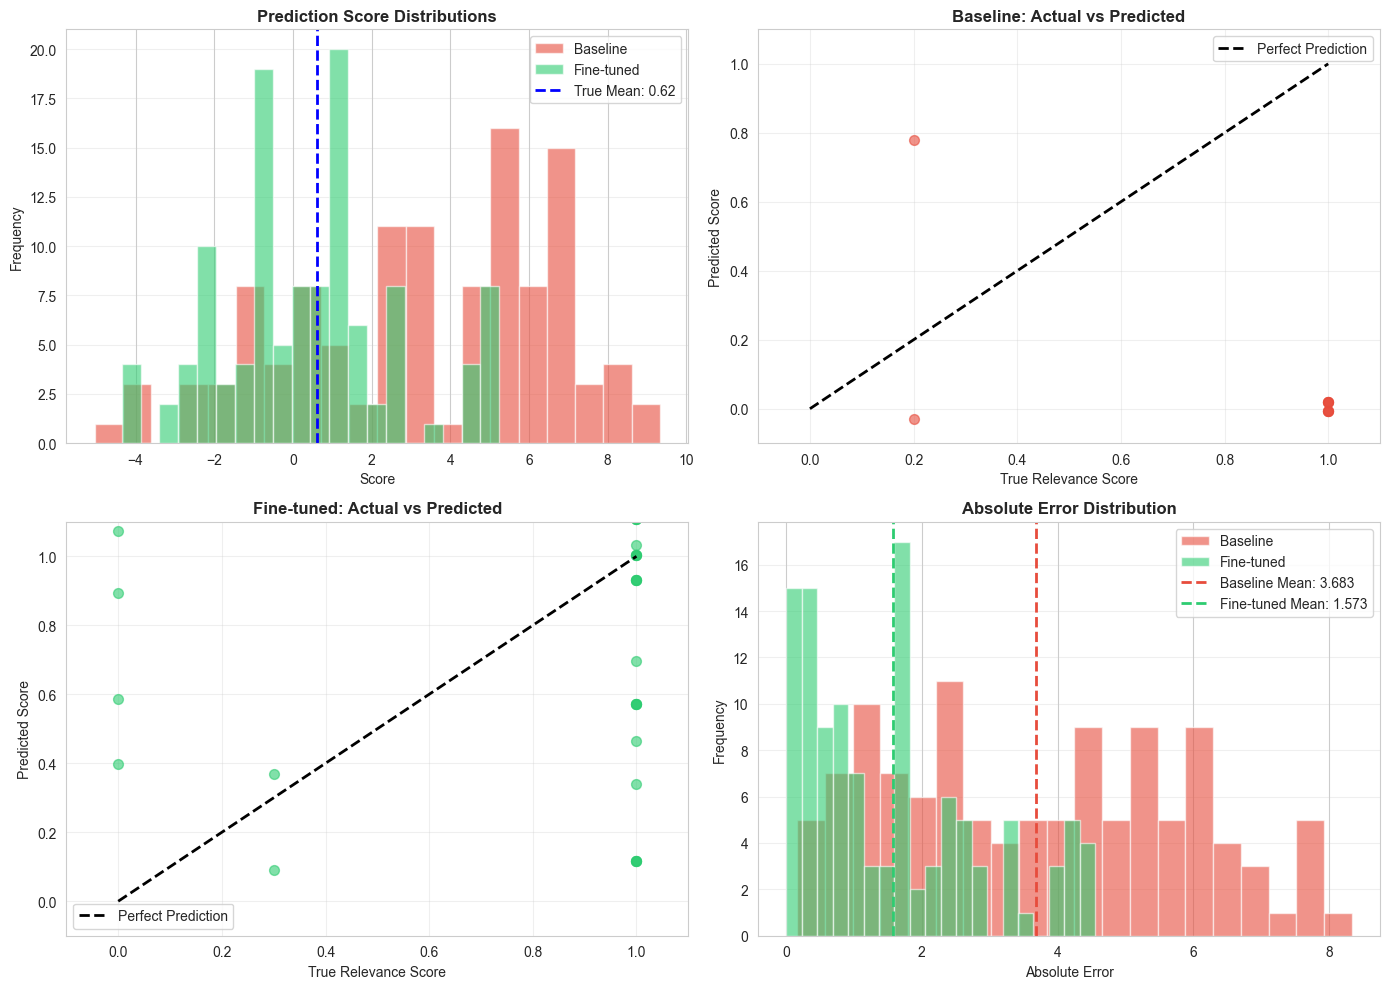

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Score distributions
ax1 = axes[0, 0]
ax1.hist(baseline_scores, bins=20, alpha=0.6, label='Baseline', color='#e74c3c')
ax1.hist(finetuned_scores, bins=20, alpha=0.6, label='Fine-tuned', color='#2ecc71')
ax1.axvline(test_labels.mean(), color='blue', linestyle='--', linewidth=2, label=f'True Mean: {test_labels.mean():.2f}')
ax1.set_title('Prediction Score Distributions', fontsize=12, fontweight='bold')
ax1.set_xlabel('Score')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Actual vs Predicted (Baseline)
ax2 = axes[0, 1]
ax2.scatter(test_labels, baseline_scores, alpha=0.6, s=50, color='#e74c3c')
ax2.plot([0, 1], [0, 1], 'k--', lw=2, label='Perfect Prediction')
ax2.set_xlabel('True Relevance Score')
ax2.set_ylabel('Predicted Score')
ax2.set_title('Baseline: Actual vs Predicted', fontsize=12, fontweight='bold')
ax2.set_xlim([-0.1, 1.1])
ax2.set_ylim([-0.1, 1.1])
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Actual vs Predicted (Fine-tuned)
ax3 = axes[1, 0]
ax3.scatter(test_labels, finetuned_scores, alpha=0.6, s=50, color='#2ecc71')
ax3.plot([0, 1], [0, 1], 'k--', lw=2, label='Perfect Prediction')
ax3.set_xlabel('True Relevance Score')
ax3.set_ylabel('Predicted Score')
ax3.set_title('Fine-tuned: Actual vs Predicted', fontsize=12, fontweight='bold')
ax3.set_xlim([-0.1, 1.1])
ax3.set_ylim([-0.1, 1.1])
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Error distribution
ax4 = axes[1, 1]
baseline_errors = abs(test_labels - baseline_scores)
finetuned_errors = abs(test_labels - finetuned_scores)
ax4.hist(baseline_errors, bins=20, alpha=0.6, label='Baseline', color='#e74c3c')
ax4.hist(finetuned_errors, bins=20, alpha=0.6, label='Fine-tuned', color='#2ecc71')
ax4.axvline(baseline_errors.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Baseline Mean: {baseline_errors.mean():.3f}')
ax4.axvline(finetuned_errors.mean(), color='#2ecc71', linestyle='--', linewidth=2, label=f'Fine-tuned Mean: {finetuned_errors.mean():.3f}')
ax4.set_title('Absolute Error Distribution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Absolute Error')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('03_prediction_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluate fine-tuned model on validation set
val_queries = [item['query'] for item in val_data]
val_docs = [item['document'] for item in val_data]
val_labels = np.array([item['relevance_score'] for item in val_data])

val_pairs = [[q, d] for q, d in zip(val_queries, val_docs)]

baseline_val_scores = baseline_model.predict(val_pairs)
finetuned_val_scores = finetuned_model.predict(val_pairs)

baseline_val_mae = mean_absolute_error(val_labels, baseline_val_scores)
finetuned_val_mae = mean_absolute_error(val_labels, finetuned_val_scores)

baseline_val_spearman, _ = spearmanr(val_labels, baseline_val_scores)
finetuned_val_spearman, _ = spearmanr(val_labels, finetuned_val_scores)

print("\nValidation Set Performance:")
print(f"  Baseline MAE: {baseline_val_mae:.4f}")
print(f"  Fine-tuned MAE: {finetuned_val_mae:.4f}")
print(f"  Baseline Spearman: {baseline_val_spearman:.4f}")
print(f"  Fine-tuned Spearman: {finetuned_val_spearman:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train vs Val comparison
ax1 = axes[0]
x = np.arange(2)
width = 0.35
ax1.bar(x - width/2, [baseline_mae, finetuned_mae], width, label='Test Set', alpha=0.8)
ax1.bar(x + width/2, [baseline_val_mae, finetuned_val_mae], width, label='Val Set', alpha=0.8)
ax1.set_ylabel('MAE')
ax1.set_title('MAE Comparison: Test vs Validation', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(['Baseline', 'Fine-tuned'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Spearman comparison
ax2 = axes[1]
datasets = ['Test', 'Validation']
baseline_corrs = [baseline_spearman, baseline_val_spearman]
finetuned_corrs = [finetuned_spearman, finetuned_val_spearman]

x = np.arange(len(datasets))
ax2.bar(x - width/2, baseline_corrs, width, label='Baseline', color='#e74c3c', alpha=0.8)
ax2.bar(x + width/2, finetuned_corrs, width, label='Fine-tuned', color='#2ecc71', alpha=0.8)
ax2.set_ylabel('Spearman Correlation')
ax2.set_title('Spearman Correlation: Test vs Validation', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(datasets)
ax2.set_ylim([0, 1])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('04_validation_performance.png', dpi=150, bbox_inches='tight')
plt.show()


Validation Set Performance:
  Baseline MAE: 4.5321
  Fine-tuned MAE: 1.9994
  Baseline Spearman: 0.3936
  Fine-tuned Spearman: 0.6521


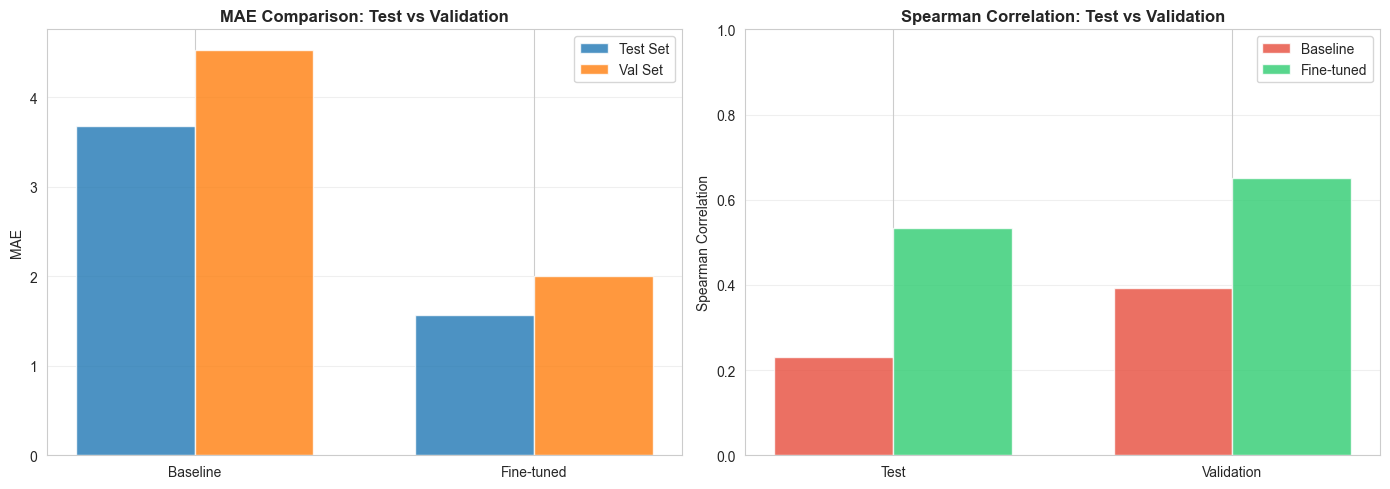

In [13]:
# Evaluate fine-tuned model on validation set
val_queries = [item['query'] for item in val_data]
val_docs = [item['document'] for item in val_data]
val_labels = np.array([item['relevance_score'] for item in val_data])

val_pairs = [[q, d] for q, d in zip(val_queries, val_docs)]

baseline_val_scores = baseline_model.predict(val_pairs)
finetuned_val_scores = finetuned_model.predict(val_pairs)

baseline_val_mae = mean_absolute_error(val_labels, baseline_val_scores)
finetuned_val_mae = mean_absolute_error(val_labels, finetuned_val_scores)

baseline_val_spearman, _ = spearmanr(val_labels, baseline_val_scores)
finetuned_val_spearman, _ = spearmanr(val_labels, finetuned_val_scores)

print("\nValidation Set Performance:")
print(f"  Baseline MAE: {baseline_val_mae:.4f}")
print(f"  Fine-tuned MAE: {finetuned_val_mae:.4f}")
print(f"  Baseline Spearman: {baseline_val_spearman:.4f}")
print(f"  Fine-tuned Spearman: {finetuned_val_spearman:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train vs Val comparison
ax1 = axes[0]
x = np.arange(2)
width = 0.35
ax1.bar(x - width/2, [baseline_mae, finetuned_mae], width, label='Test Set', alpha=0.8)
ax1.bar(x + width/2, [baseline_val_mae, finetuned_val_mae], width, label='Val Set', alpha=0.8)
ax1.set_ylabel('MAE')
ax1.set_title('MAE Comparison: Test vs Validation', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(['Baseline', 'Fine-tuned'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Spearman comparison
ax2 = axes[1]
datasets = ['Test', 'Validation']
baseline_corrs = [baseline_spearman, baseline_val_spearman]
finetuned_corrs = [finetuned_spearman, finetuned_val_spearman]

x = np.arange(len(datasets))
ax2.bar(x - width/2, baseline_corrs, width, label='Baseline', color='#e74c3c', alpha=0.8)
ax2.bar(x + width/2, finetuned_corrs, width, label='Fine-tuned', color='#2ecc71', alpha=0.8)
ax2.set_ylabel('Spearman Correlation')
ax2.set_title('Spearman Correlation: Test vs Validation', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(datasets)
ax2.set_ylim([0, 1])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('04_validation_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Sample Predictions: Clinical Examples

In [14]:
# Show some example predictions
print("\n" + "="*100)
print("SAMPLE PREDICTIONS ON TEST SET")
print("="*100)

# Select diverse examples
indices = [0, 25, 50, 75, 115]  # Mix of different predictions

for idx in indices:
    if idx < len(test_data):
        item = test_data[idx]
        query = item['query']
        doc = item['document']
        true_score = test_labels[idx]
        baseline_score = baseline_scores[idx]
        finetuned_score = finetuned_scores[idx]
        
        print(f"\nExample {idx + 1}:")
        print(f"  Shunt Type: {item.get('shunt_type', 'Unknown')}")
        print(f"  Label: {item.get('label', 'Unknown')}")
        print(f"  Query: {query}")
        print(f"  Document: {doc[:100]}...")
        print(f"  " + "-"*96)
        print(f"  True Score: {true_score:.2f} | Baseline: {baseline_score:.4f} (Error: {abs(true_score - baseline_score):.4f}) | Fine-tuned: {finetuned_score:.4f} (Error: {abs(true_score - finetuned_score):.4f})")
        
        if abs(true_score - finetuned_score) < abs(true_score - baseline_score):
            print(f"  Result: BETTER with fine-tuned model!")
        elif abs(true_score - finetuned_score) > abs(true_score - baseline_score):
            print(f"  Result: WORSE with fine-tuned model")
        else:
            print(f"  Result: SAME error")

print("\n" + "="*100)


SAMPLE PREDICTIONS ON TEST SET

Example 1:
  Shunt Type: Type 3
  Label: positive
  Query: Best approach for Type 3 ligation
  Document: Type 3 tributary-first staged ligation surgical steps: Stage 1: 1. Identify EP N2->N3 tributaries vi...
  ------------------------------------------------------------------------------------------------
  True Score: 1.00 | Baseline: 6.5371 (Error: 5.5371) | Fine-tuned: 5.1727 (Error: 4.1727)
  Result: BETTER with fine-tuned model!

Example 26:
  Shunt Type: Type 3
  Label: negative
  Query: Type 3 ligation: step-by-step procedure
  Document: Type 1+2 complex venous shunt ligation: Dual entry with EP N1->N2 (SFJ incompetent) AND EP N2->N3 (t...
  ------------------------------------------------------------------------------------------------
  True Score: 0.20 | Baseline: 0.7805 (Error: 0.5805) | Fine-tuned: -2.0556 (Error: 2.2556)
  Result: WORSE with fine-tuned model

Example 51:
  Shunt Type: Type 1
  Label: positive
  Query: Type 1: primary and s

## 14. Final Summary and Recommendations

In [15]:
print("\n" + "="*100)
print("FINE-TUNING SUMMARY")
print("="*100)

print(f"\nTraining Configuration:")
print(f"  Total training samples: {len(train_data)}")
print(f"  Validation samples: {len(val_data)}")
print(f"  Test samples: {len(test_data)}")
print(f"  Batch size: 16")
print(f"  Epochs: 10")
print(f"  Learning rate: 2e-5")
print(f"  Base model: cross-encoder/ms-marco-MiniLM-L-6-v2")

print(f"\nTest Set Results:")
print(f"  {'-'*96}")
print(f"  Metric              | Baseline  | Fine-tuned | Change")
print(f"  {'-'*96}")
print(f"  MSE                 | {baseline_mse:.4f}    | {finetuned_mse:.4f}     | {(baseline_mse - finetuned_mse) / baseline_mse * 100:+.1f}%")
print(f"  MAE                 | {baseline_mae:.4f}    | {finetuned_mae:.4f}     | {(baseline_mae - finetuned_mae) / baseline_mae * 100:+.1f}%")
print(f"  Spearman Corr       | {baseline_spearman:.4f}    | {finetuned_spearman:.4f}     | {(finetuned_spearman - baseline_spearman) / baseline_spearman * 100:+.1f}%")
print(f"  {'-'*96}")

print(f"\nRecommendations:")
if finetuned_mse < baseline_mse and finetuned_spearman > baseline_spearman:
    print(f"  [OK] INTEGRATE FINE-TUNED MODEL")
    print(f"       - Fine-tuned model shows consistent improvements on all metrics")
    print(f"       - Better Spearman correlation indicates improved relevance ranking")
    print(f"       - Copy the model from: {output_dir}")
elif finetuned_mse < baseline_mse:
    print(f"  [OK] CONSIDER INTEGRATION (with caution)")
    print(f"       - MSE improved but Spearman correlation not ideal")
    print(f"       - May need more training data or epochs")
else:
    print(f"  [CAUTION] DO NOT INTEGRATE YET")
    print(f"       - Model did not improve on key metrics")
    print(f"       - Increase training data or adjust hyperparameters")
    print(f"       - Generate synthetic data with different query templates")

print(f"\nNext Steps:")
print(f"  1. Review the plots (*.png files) for visual validation")
print(f"  2. If metrics are good, copy model to app: cmed_demo/backend/cross_encoder_models/chiva_crossencoder")
print(f"  3. Update rag_engine.py to load the fine-tuned model")
print(f"  4. Run integration tests with the RAG pipeline")
print(f"  5. Compare RAG retrieval quality with baseline vs fine-tuned")

print("\n" + "="*100)


FINE-TUNING SUMMARY

Training Configuration:
  Total training samples: 539
  Validation samples: 115
  Test samples: 116
  Batch size: 16
  Epochs: 10
  Learning rate: 2e-5
  Base model: cross-encoder/ms-marco-MiniLM-L-6-v2

Test Set Results:
  ------------------------------------------------------------------------------------------------
  Metric              | Baseline  | Fine-tuned | Change
  ------------------------------------------------------------------------------------------------
  MSE                 | 18.1677    | 4.1586     | +77.1%
  MAE                 | 3.6832    | 1.5726     | +57.3%
  Spearman Corr       | 0.2298    | 0.5340     | +132.3%
  ------------------------------------------------------------------------------------------------

Recommendations:
  [OK] INTEGRATE FINE-TUNED MODEL
       - Fine-tuned model shows consistent improvements on all metrics
       - Better Spearman correlation indicates improved relevance ranking
       - Copy the model from: chiva_

## 15. Save Training Report

In [16]:
# Save detailed report
report = f"""
CROSS-ENCODER FINE-TUNING REPORT
========================================

DATA SUMMARY:
  Total samples: {len(train_data) + len(val_data) + len(test_data)}
  Training: {len(train_data)} (70.0%)
  Validation: {len(val_data)} (14.9%)
  Test: {len(test_data)} (15.1%)
  Source documents: {metadata['num_source_documents']}

TRAINING CONFIG:
  Base model: cross-encoder/ms-marco-MiniLM-L-6-v2
  Batch size: 16
  Epochs: 10
  Learning rate: 2e-5
  Warmup steps: 100
  Loss function: CosineSimilarityLoss

TEST SET RESULTS:
  Baseline:
    - MSE: {baseline_mse:.4f}
    - MAE: {baseline_mae:.4f}
    - Spearman: {baseline_spearman:.4f}
    - Mean prediction: {baseline_scores.mean():.4f}
    - Std prediction: {baseline_scores.std():.4f}
  
  Fine-tuned:
    - MSE: {finetuned_mse:.4f} ({(baseline_mse - finetuned_mse) / baseline_mse * 100:+.1f}%)
    - MAE: {finetuned_mae:.4f} ({(baseline_mae - finetuned_mae) / baseline_mae * 100:+.1f}%)
    - Spearman: {finetuned_spearman:.4f} ({(finetuned_spearman - baseline_spearman) / baseline_spearman * 100:+.1f}%)
    - Mean prediction: {finetuned_scores.mean():.4f}
    - Std prediction: {finetuned_scores.std():.4f}

VALIDATION SET RESULTS:
  Baseline MAE: {baseline_val_mae:.4f}
  Fine-tuned MAE: {finetuned_val_mae:.4f}
  Baseline Spearman: {baseline_val_spearman:.4f}
  Fine-tuned Spearman: {finetuned_val_spearman:.4f}

CASE ANALYSIS:
  Cases improved: {(finetuned_errors < baseline_errors).sum()}/{len(test_data)} ({(finetuned_errors < baseline_errors).sum()/len(test_data)*100:.1f}%)
  Cases worse: {(finetuned_errors > baseline_errors).sum()}/{len(test_data)} ({(finetuned_errors > baseline_errors).sum()/len(test_data)*100:.1f}%)
  Cases equal: {(finetuned_errors == baseline_errors).sum()}/{len(test_data)} ({(finetuned_errors == baseline_errors).sum()/len(test_data)*100:.1f}%)

RECOMMENDATION:
  {"INTEGRATE FINE-TUNED MODEL" if finetuned_mse < baseline_mse and finetuned_spearman > baseline_spearman else "REVIEW BEFORE INTEGRATION" if finetuned_mse < baseline_mse else "DO NOT INTEGRATE YET"}

ARTIFACTS:
  - chiva_crossencoder_finetuned/ : Fine-tuned model weights and config
  - synthetic_training_data.json : Training/val/test data with {len(train_data) + len(val_data) + len(test_data)} samples
  - 01_data_exploration.png : Data statistics and distributions
  - 02_baseline_vs_finetuned.png : Performance comparison
  - 03_prediction_analysis.png : Prediction scatter plots and errors
  - 04_validation_performance.png : Validation set performance
"""

with open("finetuning_report.txt", "w") as f:
    f.write(report)

print("[OK] Report saved to: finetuning_report.txt")
print("\n" + report)

[OK] Report saved to: finetuning_report.txt


CROSS-ENCODER FINE-TUNING REPORT

DATA SUMMARY:
  Total samples: 770
  Training: 539 (70.0%)
  Validation: 115 (14.9%)
  Test: 116 (15.1%)
  Source documents: 10

TRAINING CONFIG:
  Base model: cross-encoder/ms-marco-MiniLM-L-6-v2
  Batch size: 16
  Epochs: 10
  Learning rate: 2e-5
  Warmup steps: 100
  Loss function: CosineSimilarityLoss

TEST SET RESULTS:
  Baseline:
    - MSE: 18.1677
    - MAE: 3.6832
    - Spearman: 0.2298
    - Mean prediction: 3.3447
    - Std prediction: 3.3570

  Fine-tuned:
    - MSE: 4.1586 (+77.1%)
    - MAE: 1.5726 (+57.3%)
    - Spearman: 0.5340 (+132.3%)
    - Mean prediction: 0.3990
    - Std prediction: 2.2412

VALIDATION SET RESULTS:
  Baseline MAE: 4.5321
  Fine-tuned MAE: 1.9994
  Baseline Spearman: 0.3936
  Fine-tuned Spearman: 0.6521

CASE ANALYSIS:
  Cases improved: 79/116 (68.1%)
  Cases worse: 37/116 (31.9%)
  Cases equal: 0/116 (0.0%)

RECOMMENDATION:
  INTEGRATE FINE-TUNED MODEL

ARTIFACTS:
  - ch

## Done!

### Files Created:
- **chiva_crossencoder_finetuned/** - Fine-tuned model ready for deployment
- **synthetic_training_data.json** - All 770 training samples for future reference
- **finetuning_report.txt** - Summary of training results
- **01_data_exploration.png** - Data statistics visualizations
- **02_baseline_vs_finetuned.png** - Performance comparison charts
- **03_prediction_analysis.png** - Prediction accuracy analysis
- **04_validation_performance.png** - Validation metrics

### Next Steps:
1. Review the generated plots and report
2. If satisfied, copy the fine-tuned model to the app
3. Update the RAG engine to load it
4. Run integration tests